In [16]:
import json
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
video_path = "../../../../data/partidoPrueba/08fd33_4_medio.mp4"

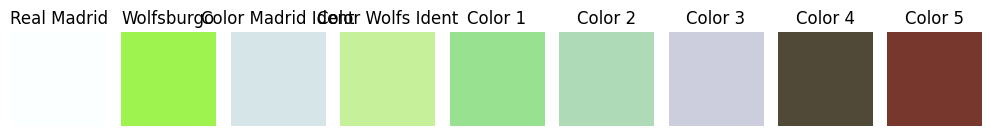

In [18]:
# l -> 200 b -> 110 a -> 125
# l-> 125 b -> 150 a -> 100

# Todos los colores en formato LAB (OpenCV)
TEAM_COLORS_LAB = {
    "Real Madrid": np.array([[[255, 127, 127]]], dtype=np.uint8),
    "Wolfsburgo":  np.array([[[224, 77, 196]]], dtype=np.uint8),
    
    "Color Madrid Ident":      np.array([[[230, 123, 125]]], dtype=np.uint8),
    "Color Wolfs Ident":      np.array([[[230, 100, 165]]], dtype=np.uint8),

    "Color 1":      np.array([[[212, 90, 160]]], dtype=np.uint8),
    "Color 2":      np.array([[[212, 107, 140]]], dtype=np.uint8),
    "Color 3":      np.array([[[212, 130, 120]]], dtype=np.uint8),
    "Color 4":      np.array([[[80, 128, 140]]], dtype=np.uint8),
    "Color 5":      np.array([[[80, 155, 147]]], dtype=np.uint8),
}

# Convertir de Lab (cv2) -> BGR -> RGB
colors_rgb = {
    name: cv2.cvtColor(val, cv2.COLOR_LAB2BGR)[0, 0][::-1]  # convierto a RGB
    for name, val in TEAM_COLORS_LAB.items()
}

# Mostrar con matplotlib
fig, axes = plt.subplots(1, 9, figsize=(10, 3))
for ax, (name, color) in zip(axes, colors_rgb.items()):
    ax.imshow(np.ones((100, 100, 3), dtype=np.uint8) * color)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
with open("tracks3.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [20]:
reformed_data = []
i = 0
for exp in data:
    base_data = { k:v for k,v in exp.items() if k != "track" }
    for class_name, class_info in exp["track"].items():
        for n_frame, frame_tracks in enumerate(class_info):
            for tracker_id, player_dict in frame_tracks.items():
                row = base_data.copy()
                row.update({'class_name': class_name, 'frame': n_frame, 'tracker_id': tracker_id})
                row.update({
                    "x1": player_dict["bbox"][0],
                    "y1": player_dict["bbox"][1],
                    "w": player_dict["bbox"][2] - player_dict["bbox"][0],
                    "h": player_dict["bbox"][3] - player_dict["bbox"][1],
                    "bbox_size": player_dict["bbox_size"],
                    "confidence": player_dict["confidence"],
                    "Real Madrid": player_dict["distances"]["Real Madrid"],
                    "Wolfsburgo": player_dict["distances"]["Wolfsburgo"],
                    "L": player_dict["shirt_color"][0],
                    "A": player_dict["shirt_color"][1],
                    "B": player_dict["shirt_color"][2],
                    "team": player_dict["team"]
                } )
                reformed_data.append(row)

df = pd.DataFrame(reformed_data)
df

,conf,mcf,mt,tt,class_name,frame,tracker_id,x1,y1,w,h,bbox_size,confidence,Real Madrid,Wolfsburgo,L,A,B,team
0,0.01,1,0.933,0.1,ball,0,23,1186.531494,848.252991,17.196899,18.936218,969,0.368043,11.816157,35.026048,228.339623,118.773585,135.452830,Real Madrid
1,0.01,1,0.933,0.1,ball,1,23,1186.724854,847.940369,16.663696,19.292908,1020,0.322803,11.888387,37.069459,224.210526,119.701754,134.140351,Real Madrid
2,0.01,1,0.933,0.1,ball,15,27,1217.013428,720.452637,47.154663,92.119263,5478,0.012704,183.791802,187.411972,46.982759,123.876437,133.597701,Real Madrid
3,0.01,1,0.933,0.1,ball,88,115,257.489349,794.939392,15.883118,23.411865,1152,0.575783,12.964277,41.778587,240.974359,123.769231,132.307692,Real Madrid
4,0.01,1,0.933,0.1,ball,89,115,258.835266,790.507507,14.205688,22.799194,1035,0.549380,8.498866,41.266353,226.322581,124.387097,131.870968,Real Madrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426603,0.20,10,1.000,0.7,referee,195,3,798.576294,275.170807,12.810608,37.161102,4356,0.747764,29.224592,59.854649,202.060185,125.004630,118.462963,Real Madrid
426604,0.20,10,1.000,0.7,referee,196,3,797.570618,275.090576,12.941162,37.297607,3960,0.737760,5.280152,45.231591,226.215385,124.569231,127.192308,Real Madrid
426605,0.20,10,1.000,0.7,referee,197,3,797.412048,275.300659,12.984009,37.230194,4095,0.729366,3.432941,47.649502,227.312217,123.597285,123.687783,Real Madrid
426606,0.20,10,1.000,0.7,referee,198,3,797.832275,274.968567,13.224609,36.390930,3078,0.748680,53.653958,21.895477,209.645570,92.898734,163.835443,Wolfsburgo


In [21]:
df_indexed = df.set_index(["conf", "mcf", "mt", "tt", "class_name", "frame", "tracker_id"])
df_indexed

x1          y1  \
conf mcf mt    tt  class_name frame tracker_id                            
0.01 1   0.933 0.1 ball       0     23          1186.531494  848.252991   
                              1     23          1186.724854  847.940369   
                              15    27          1217.013428  720.452637   
                              88    115          257.489349  794.939392   
                              89    115          258.835266  790.507507   
...                                                     ...         ...   
0.20 10  1.000 0.7 referee    195   3            798.576294  275.170807   
                              196   3            797.570618  275.090576   
                              197   3            797.412048  275.300659   
                              198   3            797.832275  274.968567   
                              199   3            797.994324  274.800201   

                                                        w          h  \
conf mcf mt    tt  class_name frame tracker_id                         
0.01 1   0.933 0.1 ball       0     23          17.196899  18.936218   
                              1     23          16.663696  19.292908   
                              15    27          47.154663  92.119263   
                              88    115         15.883118  23.411865   
                              89    115         14.205688  22.799194   
...                                                   ...        ...   
0.20 10  1.000 0.7 referee    195   3           12.810608  37.161102   
                              196   3           12.941162  37.297607   
                              197   3           12.984009  37.230194   
                              198   3           13.224609  36.390930   
                              199   3           13.296021  36.511261   

                                                bbox_size  confidence  \
conf mcf mt    tt  class_name frame tracker_id                          
0.01 1   0.933 0.1 ball       0     23                969    0.368043   
                              1     23               1020    0.322803   
                              15    27               5478    0.012704   
                              88    115              1152    0.575783   
                              89    115              1035    0.549380   
...                                                   ...         ...   
0.20 10  1.000 0.7 referee    195   3                4356    0.747764   
                              196   3                3960    0.737760   
                              197   3                4095    0.729366   
                              198   3                3078    0.748680   
                              199   3                4725    0.752721   

                                                Real Madrid  Wolfsburgo  \
conf mcf mt    tt  class_name frame tracker_id                            
0.01 1   0.933 0.1 ball       0     23            11.816157   35.026048   
                              1     23            11.888387   37.069459   
                              15    27           183.791802  187.411972   
                              88    115           12.964277   41.778587   
                              89    115            8.498866   41.266353   
...                                                     ...         ...   
0.20 10  1.000 0.7 referee    195   3             29.224592   59.854649   
                              196   3              5.280152   45.231591   
                              197   3              3.432941   47.649502   
                              198   3             53.653958   21.895477   
                              199   3             58.604924   22.757377   

                                                         L           A  \
conf mcf mt    tt  class_name frame tracker_id                           
0.01 1   0.933 0.1 ball       0     23          228.339623  118.773585

In [22]:
def show_hist(axes, df, class_name, c1, c2, c3):
    axes[0].hist(df[c1], bins=256), axes[0].set_title(c1), axes[0].set_xlabel("Intensidad"), axes[0].grid(), axes[0].set_ylabel(f"Freq {class_name}")
    axes[1].hist(df[c2], bins=256), axes[1].set_title(c2), axes[1].set_xlabel("Intensidad"), axes[1].grid()
    axes[2].hist(df[c3], bins=256), axes[2].set_title(c3), axes[2].set_xlabel("Intensidad"), axes[2].grid()

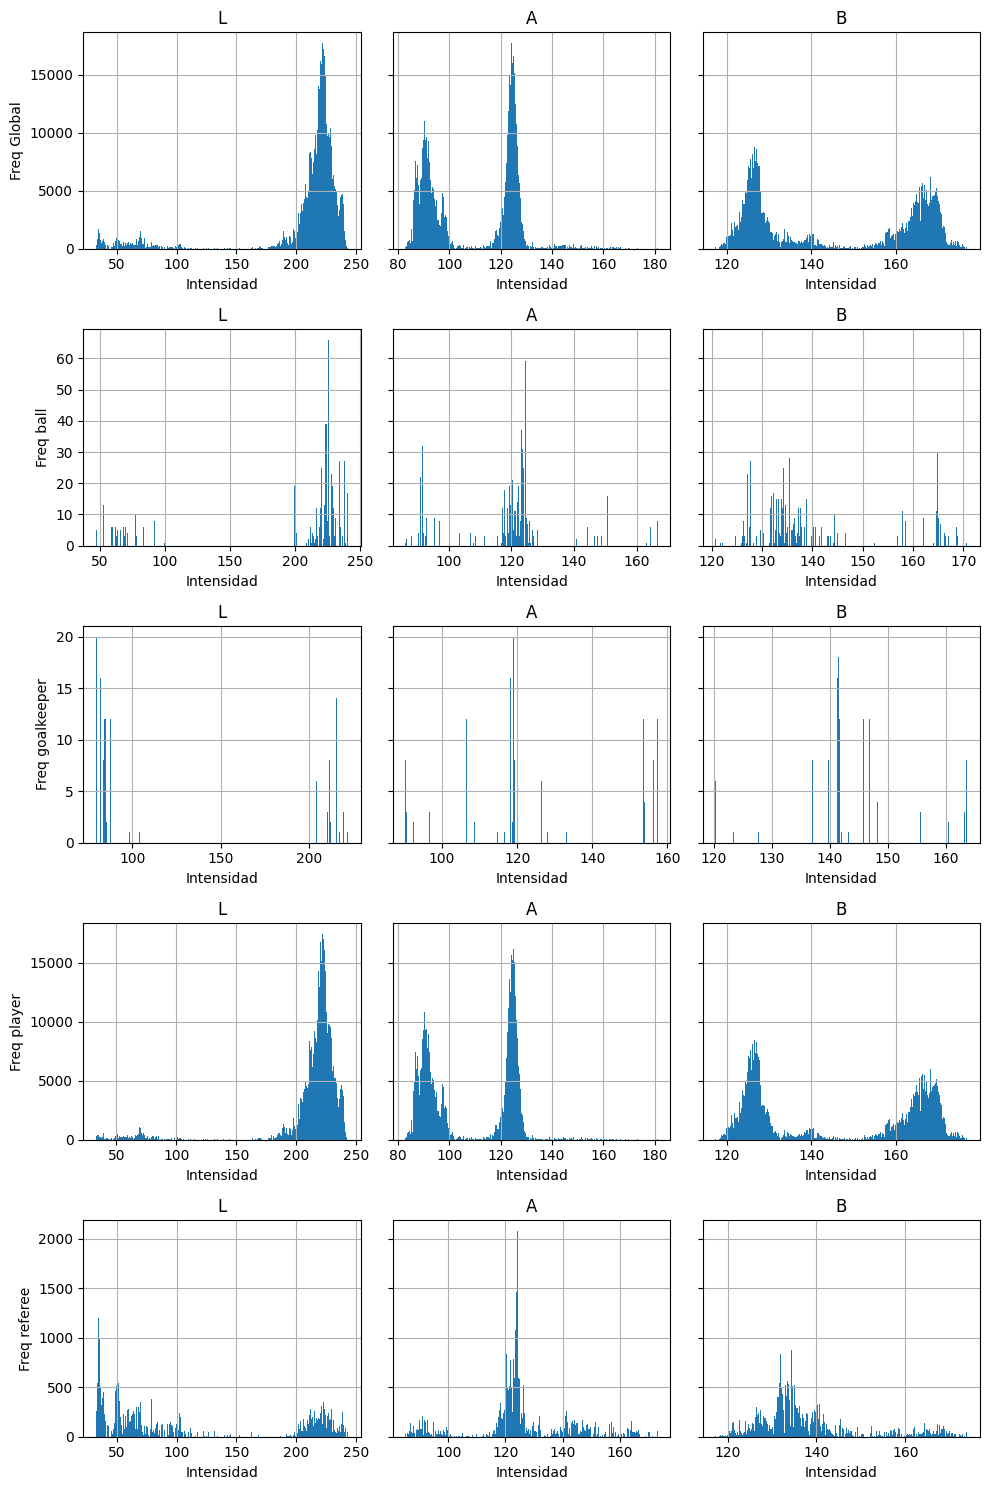

In [23]:
fig, axes = plt.subplots(5, 3, figsize=(10, 15), sharey="row")

show_hist(axes[0], df, "Global", "L", "A", "B")
for i, class_name in enumerate(df["class_name"].unique()):
    aux = df[df["class_name"]==class_name]
    show_hist(axes[i+1], aux, class_name, "L", "A", "B")

plt.tight_layout()
plt.show()

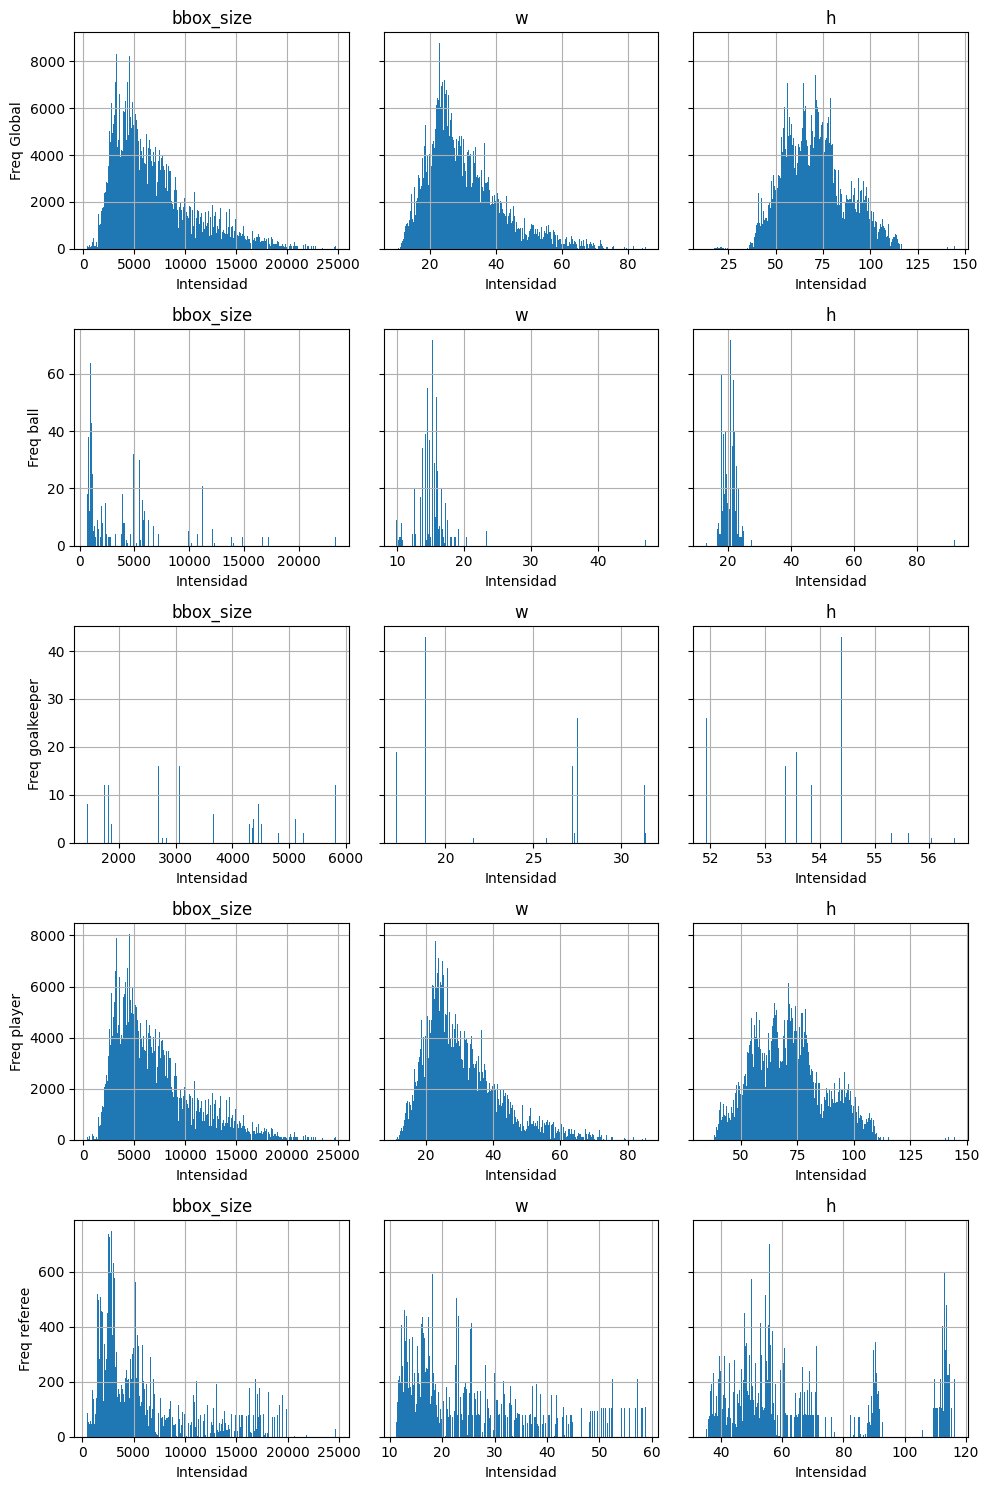

In [24]:
fig, axes = plt.subplots(5, 3, figsize=(10, 15), sharey="row")

show_hist(axes[0], df, "Global", "bbox_size", "w", "h")
for i, class_name in enumerate(df["class_name"].unique()):
    aux = df[df["class_name"]==class_name]
    show_hist(axes[i+1], aux, class_name, "bbox_size", "w", "h")

plt.tight_layout()
plt.show()

In [25]:
def showExample(df, filtro):
    if filtro is not None:
        df = df.drop_duplicates(subset=[filtro])
    n_boxes = len(df)
    n_cols = 16
    n_rows = (n_boxes + n_cols - 1) // n_cols  # Cálculo para redondear hacia arriba

    if n_rows == 1:
        fig, axes = plt.subplots(1, n_cols, figsize=(16, 2 * n_rows))
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2 * n_rows))
        axes = axes.flatten()
    cap = cv2.VideoCapture(video_path)

    for idx, (index, row) in enumerate(df.iterrows()):
        if idx >= len(axes):
            break
        # frame_idx = index[0]  # primer nivel del índice (frame)
        frame_idx = row["frame"]
        bbox = [int(row["x1"]), int(row["y1"]), int(row["w"]), int(row["h"])]
        bbox_size = row["bbox_size"]
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            x1, y1, w, h = bbox
            bbox_crop = frame_rgb[y1:y1+h, x1:x1+w]
            axes[idx].imshow(bbox_crop)
            axes[idx].set_title(f"Frame: {frame_idx}\nSize: {bbox_size}")
            axes[idx].axis('off')
        else:
            axes[idx].text(0.5, 0.5, f"Frame {frame_idx}\nnot found", ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].axis('off')

    for idx in range(len(df), len(axes)):
        axes[idx].axis('off')

    cap.release()
    plt.tight_layout()
    plt.show()

In [26]:
def showClusters(df, n_clusters=2, init='k-means++', n_init=10, random_state=0):
    km = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, random_state=random_state)
    bbox_info = []
    
    cap = cv2.VideoCapture(video_path)
    
    for _, row in df.iterrows():
        frame_idx = row["frame"]
        x1, y1, w, h = [int(row["x1"]), int(row["y1"]), int(row["w"]), int(row["h"])]
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            bbox_full = frame_rgb[y1:y1+h, x1:x1+w]
            if bbox_full.size > 0 and h > 0:
                bbox_upper = bbox_full[:h // 2, :]
                bbox_flat = bbox_upper.reshape(-1, 3)  # (64*64, 3)
                km.fit(bbox_flat)
                predictions = km.predict(bbox_flat)
                clustered = km.cluster_centers_[predictions].astype(np.uint8)
                clustered_img = clustered.reshape(h // 2, w, 3)
                bbox_info.append({
                    'frame_idx': frame_idx, 'bbox_size': row["bbox_size"],
                    'upper_bbox': bbox_upper, 'clustered': clustered_img,
                    'team': row.get('team', 'Unknown')
                })
    
    cap.release()
    
    n_samples = len(bbox_info)
    n_cols = 8
    n_rows = math.ceil(n_samples / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(25, 3*n_rows))
    axes = np.array(axes).reshape(-1)
    
    for i in range(n_samples):
        info = bbox_info[i]
        axes[i].imshow(np.hstack((info['upper_bbox'], info['clustered'])))
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

    return bbox_info

In [27]:
def showPlot(df, nparray):
    TEAM_COLORS = { "Madrid": np.array([255, 127, 127]),       "Wolfs":  np.array([224, 77, 196]), 
                "Madrid Ident": np.array([230, 123, 125]),  "Wolfs Ident":  np.array([230, 100, 165]) }

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')

    mask = df["team"]=="Real Madrid"
    ax.scatter(df[mask]["L"], df[mask]["A"], df[mask]["B"], c="blue", label="Real Madrid", s=10, alpha=0.7)
    ax.scatter(df[~mask]["L"], df[~mask]["A"], df[~mask]["B"], c="red", label="Wolfsburgo", s=10, alpha=0.7)

    ax.scatter([TEAM_COLORS["Madrid"][0]], [TEAM_COLORS["Madrid"][1]], [TEAM_COLORS["Madrid"][2]], c="orange", label="Madrid - Color Oficial", s=100, marker='*', edgecolors='black', linewidth=1)
    ax.scatter([TEAM_COLORS["Wolfs"][0]], [TEAM_COLORS["Wolfs"][1]], [TEAM_COLORS["Wolfs"][2]], c="yellow", label="Wolfsb - Color Oficial",  s=100, marker='*', edgecolors='black', linewidth=1)
    ax.scatter([TEAM_COLORS["Madrid Ident"][0]], [TEAM_COLORS["Madrid Ident"][1]], [TEAM_COLORS["Madrid Ident"][2]], c="orange", label="Madrid Ident", s=150, marker='^', edgecolors='black', linewidth=1)
    ax.scatter([TEAM_COLORS["Wolfs Ident"][0]], [TEAM_COLORS["Wolfs Ident"][1]], [TEAM_COLORS["Wolfs Ident"][2]], c="yellow", label="Wolfsb Ident",  s=150, marker='^', edgecolors='black', linewidth=1)

    ax.scatter(nparray[:, 0], nparray[:, 1], nparray[:, 2], c="orange", label="otro", s=10, alpha=0.7)

    ax.set_xlabel('L'), ax.set_ylabel('A'), ax.set_zlabel('B'), ax.set_title('Espacio de Color LAB por Equipo')

    plt.tight_layout(), plt.legend()
    plt.show()

In [28]:
def mostrar_colores_lab(colores_lab):
    colores_lab = np.array(colores_lab, dtype=np.uint8).reshape(-1, 1, 3)
    colores_rgb = cv2.cvtColor(colores_lab, cv2.COLOR_LAB2RGB)
    n = len(colores_rgb)
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2))
    if n == 1:
        axes = [axes]
    for ax, color in zip(axes, colores_rgb):
        ax.imshow(np.ones((50, 50, 3), dtype=np.uint8) * color), ax.axis("off")
    plt.show()

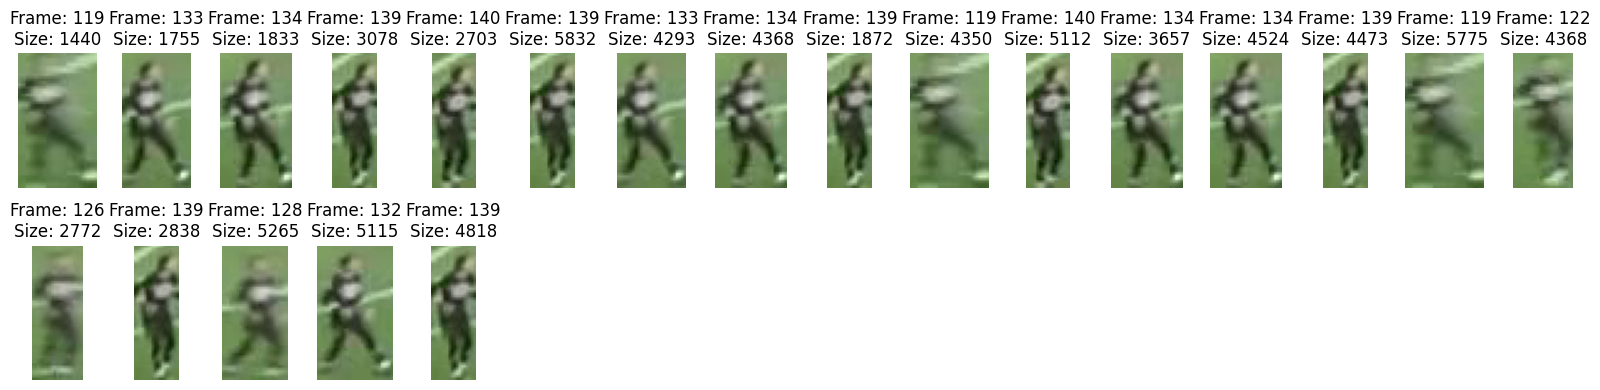

In [29]:
showExample(df[(df["class_name"]=="goalkeeper")], "L")

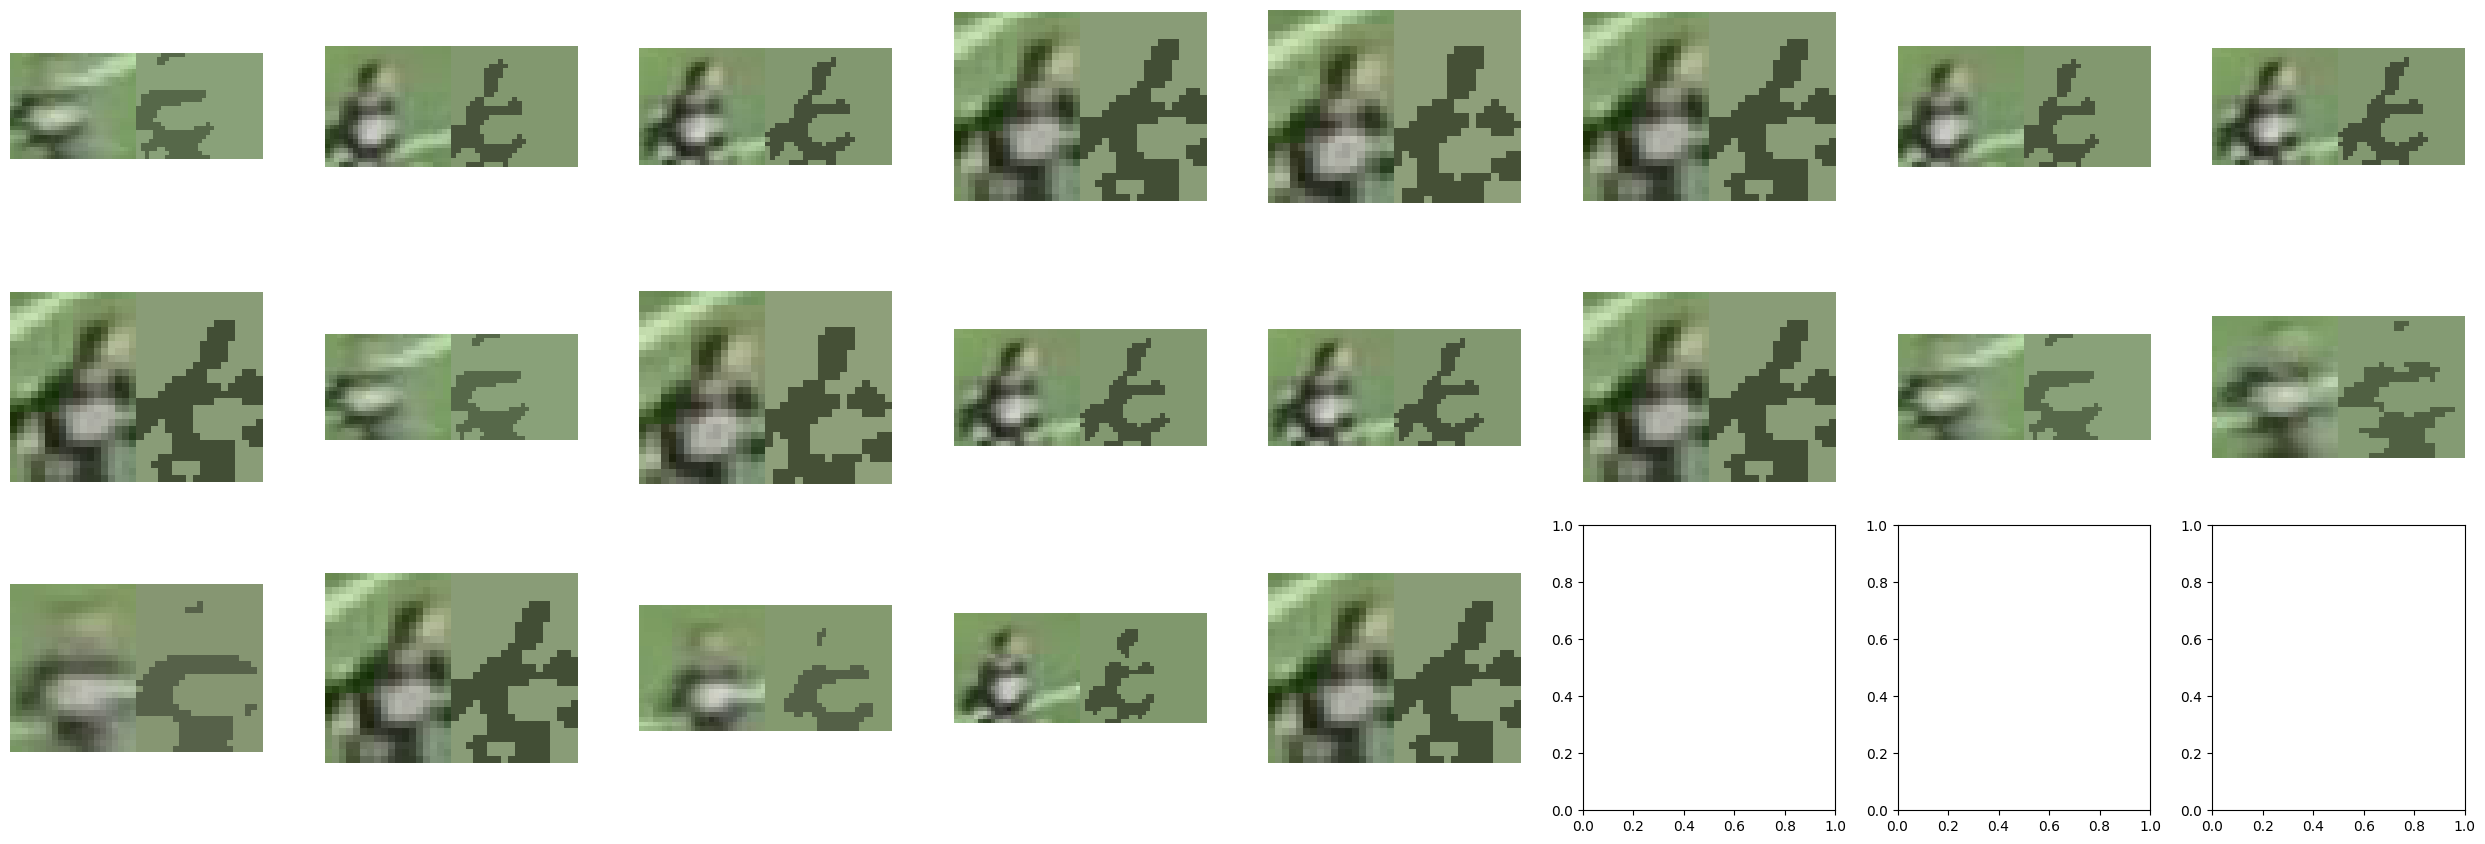

In [30]:
clusters_info = showClusters(df[(df["class_name"]=="goalkeeper")].drop_duplicates(subset=["L"]))

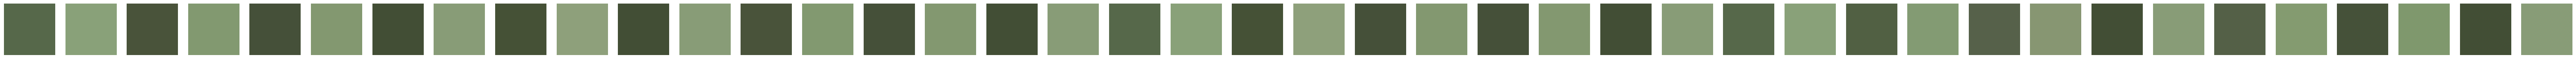

In [34]:
colores_menos_repetidos = []
for objeto in clusters_info:
    colores, counts = np.unique(objeto["clustered"].reshape(-1, 3), axis=0, return_counts=True)
    color_menos_repetido = colores[np.argmin(counts)].reshape(1, 1, 3).astype(np.uint8)
    color_mas_repetido = colores[np.argmax(counts)].reshape(1, 1, 3).astype(np.uint8)
    colores_menos_repetidos.append(cv2.cvtColor(color_menos_repetido, cv2.COLOR_RGB2LAB))
    colores_menos_repetidos.append(cv2.cvtColor(color_mas_repetido, cv2.COLOR_RGB2LAB))

mostrar_colores_lab(colores_menos_repetidos)

In [32]:
def showPlotNP(nparray):
    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(nparray[:, 0], nparray[:, 1], nparray[:, 2], c="orange", label="otro", s=10, alpha=0.7)
    ax.set_xlabel('L'), ax.set_ylabel('A'), ax.set_zlabel('B'), ax.set_title('Espacio de Color LAB por Equipo')
    plt.tight_layout(), plt.legend()
    plt.show()

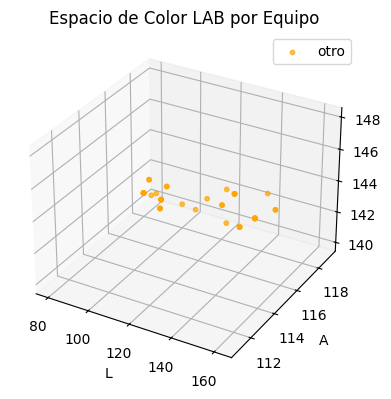

In [35]:
showPlotNP(np.array(colores_menos_repetidos).reshape(-1, 3))

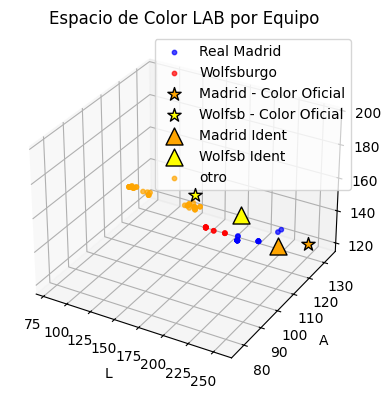

In [36]:
showPlot(df[(df["class_name"]=="goalkeeper") & (df["L"]>150)], np.array(colores_menos_repetidos).reshape(-1, 3))